In [1]:
import pandas as pd

import numpy as np

import shap

import xgboost as xgb

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../processed/features_dataset.csv"
)

In [3]:
print(df.head())

print(df.shape)

   max_similarity  mean_similarity  max_entailment  max_contradiction  \
0        0.493778         0.490406             0.0           0.000000   
1        0.542135         0.510072             0.0           0.000000   
2        0.416591         0.401467             0.0           0.000000   
3        0.386189         0.385280             0.0           0.502376   
4        0.400931         0.397153             0.0           0.000000   

   max_neutral  claim_length  entity_count  number_count  negation_present  \
0     0.999059            13             7             0                 0   
1     0.998905            17             7             0                 0   
2     0.994209            18             3             0                 0   
3     0.928322            26             5             0                 0   
4     0.988057            23            11             0                 0   

   evidence_count  avg_word_length  punctuation_count  unique_word_ratio  \
0               

In [4]:
X = df.drop("label", axis=1)

y = df["label"]

In [5]:
X = df.drop("label", axis=1)

y = df["label"]

In [6]:
xgb_model = xgb.XGBClassifier()

xgb_model.load_model(
    "../models/xgboost_model.json"
)

In [7]:
explainer = shap.TreeExplainer(
    xgb_model
)

In [8]:
sample_X = X.sample(
    500,
    random_state=42
)

In [9]:
shap_values = explainer.shap_values(
    sample_X
)

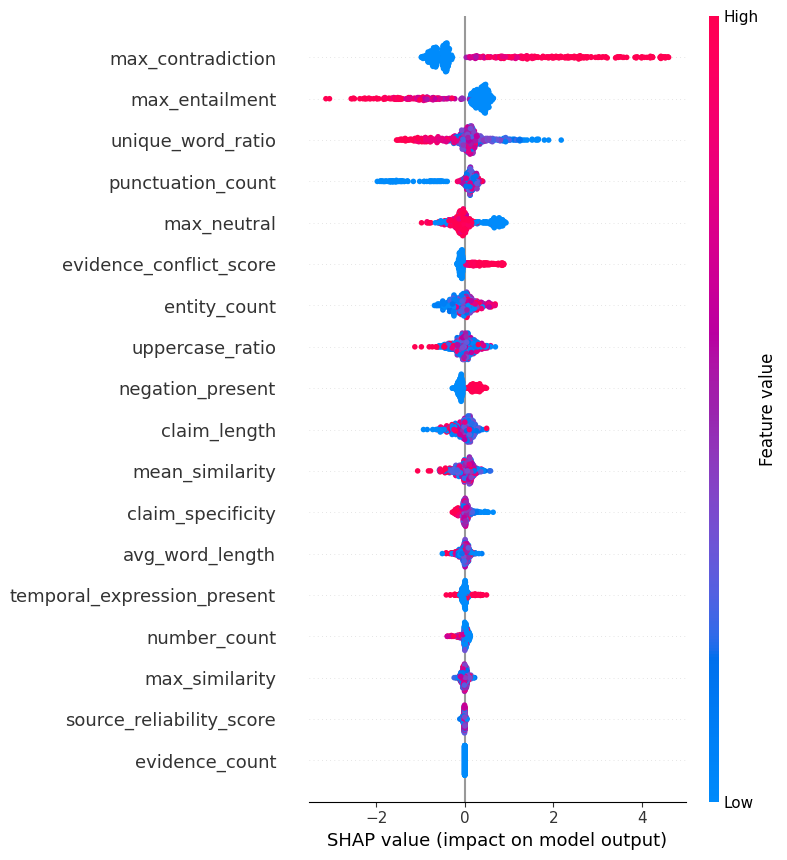

In [10]:
shap.summary_plot(
    shap_values,
    sample_X
)

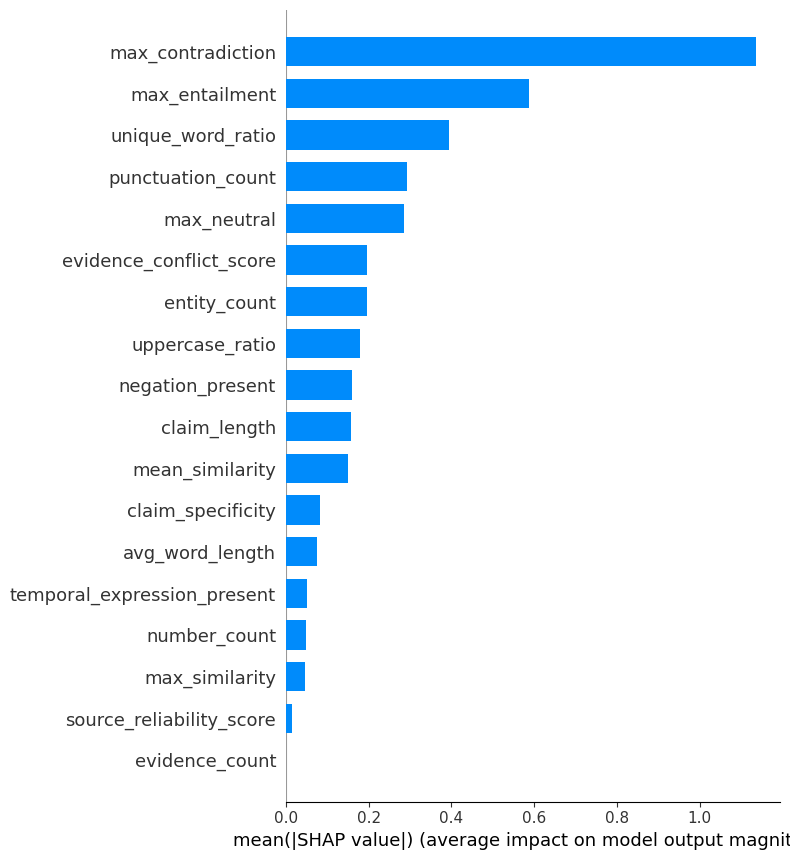

In [11]:
shap.summary_plot(
    shap_values,
    sample_X,
    plot_type="bar"
)

In [12]:
sample_instance = sample_X.iloc[[0]]

In [13]:
sample_shap = explainer.shap_values(
    sample_instance
)

In [14]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    sample_shap[0],
    sample_instance
)

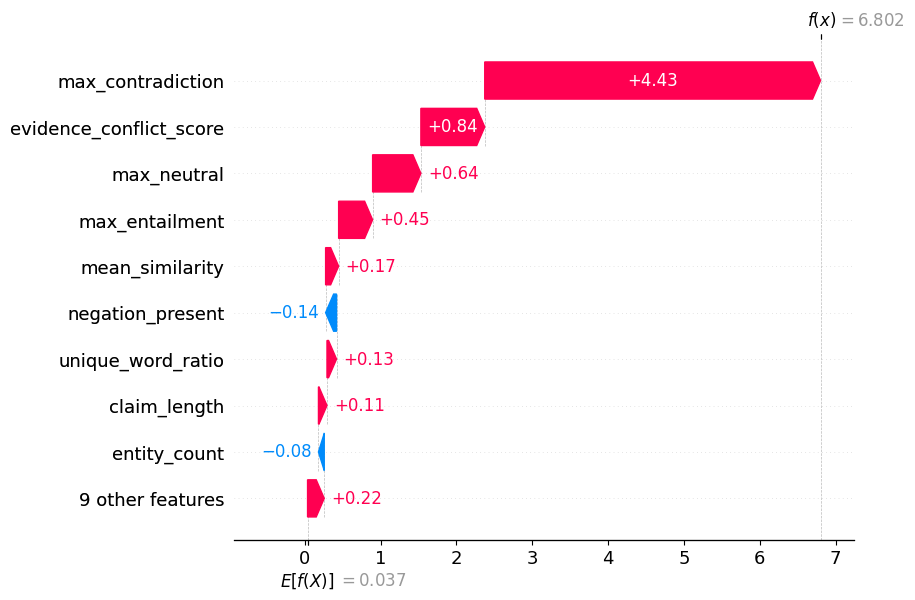

In [15]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    sample_shap[0],
    feature_names=sample_instance.columns
)

In [16]:
importance_df = pd.DataFrame({

    "feature": X.columns,

    "mean_abs_shap":
        np.abs(shap_values).mean(axis=0)
})

importance_df = importance_df.sort_values(
    by="mean_abs_shap",
    ascending=False
)

print(importance_df)

                        feature  mean_abs_shap
3             max_contradiction       1.137615
2                max_entailment       0.586859
12            unique_word_ratio       0.395581
11            punctuation_count       0.293127
4                   max_neutral       0.285682
15      evidence_conflict_score       0.196896
6                  entity_count       0.195983
13              uppercase_ratio       0.179649
8              negation_present       0.160751
5                  claim_length       0.156940
1               mean_similarity       0.149653
17            claim_specificity       0.082109
10              avg_word_length       0.074946
14  temporal_expression_present       0.050347
7                  number_count       0.048604
0                max_similarity       0.045856
16     source_reliability_score       0.015128
9                evidence_count       0.000000


In [17]:
importance_df.to_csv(
    "../outputs/shap_feature_importance.csv",
    index=False
)

In [18]:
print("SHAP explainability completed successfully!")

SHAP explainability completed successfully!
